# 📊 Sales Data Analysis

## 1. Imports

In [19]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving sales_data_sample.csv to sales_data_sample (1).csv
User uploaded file "sales_data_sample (1).csv" with length 527958 bytes


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## 2. Data Loading & Initial Inspection

In [21]:
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [23]:
df.shape

(2823, 25)

In [24]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


## 3. Data Cleaning

In [25]:
# Check duplicates
print(df.duplicated().sum())

0


In [26]:
# Convert date column
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [27]:
# Fill nulls
df['PHONE']        = df['PHONE'].fillna('Unknown')
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('Unknown')
df['STATE']        = df['STATE'].fillna('Unknown')
df['POSTALCODE']   = df['POSTALCODE'].fillna('Unknown')
df['TERRITORY']    = df['TERRITORY'].fillna('Unknown')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

## 4. Exploratory Data Analysis (EDA)

### 4.1 Status & Product Line

In [28]:
df.value_counts('STATUS')

,count
STATUS,
Shipped,2617
Cancelled,60
Resolved,47
On Hold,44
In Process,41
Disputed,14


In [29]:
df.value_counts('STATUS', normalize=True)

,proportion
STATUS,
Shipped,0.927028
Cancelled,0.021254
Resolved,0.016649
On Hold,0.015586
In Process,0.014524
Disputed,0.004959


In [30]:
df.value_counts('PRODUCTLINE')

,count
PRODUCTLINE,
Classic Cars,967
Vintage Cars,607
Motorcycles,331
Planes,306
Trucks and Buses,301
Ships,234
Trains,77


In [31]:
df.value_counts('PRODUCTLINE', normalize=True)

,proportion
PRODUCTLINE,
Classic Cars,0.342543
Vintage Cars,0.215019
Motorcycles,0.117251
Planes,0.108395
Trucks and Buses,0.106624
Ships,0.082891
Trains,0.027276


### 4.2 Orders by Year

In [32]:

df.value_counts('YEAR_ID')

,count
YEAR_ID,
2004,1345
2003,1000
2005,478


In [33]:
df.value_counts('YEAR_ID', normalize=True)

,proportion
YEAR_ID,
2004,0.476443
2003,0.354233
2005,0.169323


In [34]:
# Orders per year grouped with status
result = df.groupby(['STATUS', 'YEAR_ID'])['ORDERNUMBER'].count()
result

STATUS      YEAR_ID
Cancelled   2003         16
            2004         44
Disputed    2005         14
In Process  2005         41
On Hold     2004          6
            2005         38
Resolved    2003          8
            2004          8
            2005         31
Shipped     2003        976
            2004       1287
            2005        354
Name: ORDERNUMBER, dtype: int64

### 4.3 Territory Analysis

In [35]:
df['TERRITORY'].value_counts()

,count
TERRITORY,
EMEA,1407
Unknown,1074
APAC,221
Japan,121


In [36]:
# USA territory is all null; 70 nulls belong to Canada, 1004 to USA
df[df['COUNTRY'] == 'USA']['TERRITORY'].value_counts()

,count
TERRITORY,
Unknown,1004


In [37]:
df[df['COUNTRY'] == 'Canada']['TERRITORY'].value_counts()

,count
TERRITORY,
Unknown,70


### 4.4 Country Analysis

In [38]:
df['COUNTRY'].value_counts()

,count
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


In [39]:
# Top 5 countries by order count
top_five = df.groupby('COUNTRY')['ORDERNUMBER'].count().sort_values(ascending=False).head()
top_five

,ORDERNUMBER
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144


### 4.5 Sales Filters

In [40]:
# Orders with sales > 10,000 by country
df[df['SALES'] > 10000].groupby('COUNTRY')['ORDERNUMBER'].count()

,ORDERNUMBER
COUNTRY,
Denmark,1
Finland,1
France,3
Japan,1
Singapore,1
Spain,2
UK,1
USA,6


In [41]:
# Total sales by country
df['SALES'].groupby(df['COUNTRY']).sum().sort_values(ascending=False)

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46
Italy,374674.31
Finland,329581.91
Norway,307463.70
Singapore,288488.41


In [42]:
# Order count by country
df['SALES'].groupby(df['COUNTRY']).count().sort_values(ascending=False)

,SALES
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


In [43]:
# Average sales by country (Denmark has high avg due to high order values)
avg_sales = (
    df['SALES'].groupby(df['COUNTRY']).sum() /
    df['SALES'].groupby(df['COUNTRY']).count()
).sort_values(ascending=False)
avg_sales

,SALES
COUNTRY,
Denmark,3899.002381
Switzerland,3797.211613
Sweden,3684.459825
Austria,3673.864182
Singapore,3651.752025
Japan,3618.611731
Norway,3617.220000
Philippines,3615.989615
USA,3613.528715


In [44]:
# Top 10 orders by sales value
df.sort_values('SALES', ascending=False).head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
598,10407,76,100.0,2,14082.8,2005-04-22,On Hold,2,4,2005,...,3086 Ingle Ln.,Unknown,San Jose,CA,94217,USA,Unknown,Frick,Sue,Large
744,10322,50,100.0,6,12536.5,2004-11-04,Shipped,4,11,2004,...,2304 Long Airport Avenue,Unknown,Nashua,NH,62005,USA,Unknown,Young,Valarie,Large
53,10424,50,100.0,6,12001.0,2005-05-31,In Process,2,5,2005,...,"C/ Moralzarzal, 86",Unknown,Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Large
1062,10412,60,100.0,9,11887.8,2005-05-03,Shipped,2,5,2005,...,"C/ Moralzarzal, 86",Unknown,Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Large
104,10403,66,100.0,9,11886.6,2005-04-08,Shipped,2,4,2005,...,Berkeley Gardens 12 Brewery,Unknown,Liverpool,Unknown,WX1 6LT,UK,EMEA,Devon,Elizabeth,Large
1995,10405,76,100.0,3,11739.7,2005-04-14,Shipped,2,4,2005,...,"24, place Kluber",Unknown,Strasbourg,Unknown,67000,France,EMEA,Citeaux,Frederique,Large
44,10312,48,100.0,3,11623.7,2004-10-21,Shipped,4,10,2004,...,5677 Strong St.,Unknown,San Rafael,CA,97562,USA,Unknown,Nelson,Valarie,Large
1133,10333,46,100.0,2,11336.7,2004-11-18,Shipped,4,11,2004,...,5557 North Pendale Street,Unknown,San Francisco,CA,Unknown,USA,Unknown,Murphy,Julie,Large
188,10127,46,100.0,2,11279.2,2003-06-03,Shipped,2,6,2003,...,4092 Furth Circle,Suite 400,NYC,NY,10022,USA,Unknown,Young,Jeff,Large
30,10150,45,100.0,8,10993.5,2003-09-19,Shipped,3,9,2003,...,"Bronz Sok., Bronz Apt. 3/6 Tesvikiye",Unknown,Singapore,Unknown,79903,Singapore,Japan,Natividad,Eric,Large


### 4.6 IQR / Outlier Check

In [45]:

q1, q3 = np.quantile(df['SALES'], [0.25, 0.75])
IQR = q3 - q1
print('Q1:', q1)
print('Q3:', q3)
print('IQR:', IQR)

Q1: 2203.4300000000003
Q3: 4508.0
IQR: 2304.5699999999997


## 5. Visualizations

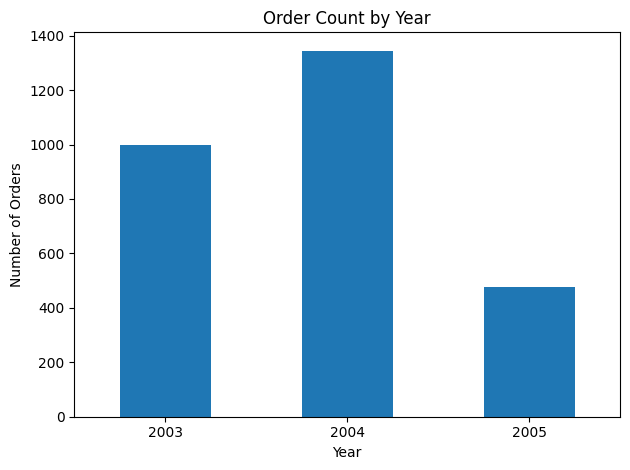

In [46]:
# Orders by Year
orders_by_year = df.groupby('YEAR_ID')['ORDERNUMBER'].count()
orders_by_year.plot(kind='bar')
plt.title('Order Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

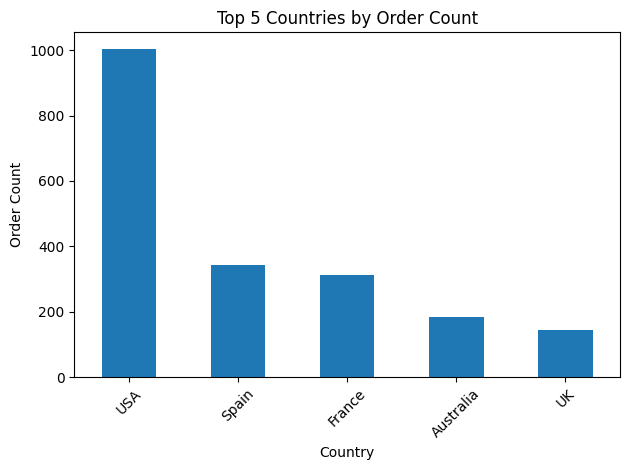

In [47]:
# Top 5 Countries - Bar Chart
top_five.plot(kind='bar')
plt.title('Top 5 Countries by Order Count')
plt.xlabel('Country')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

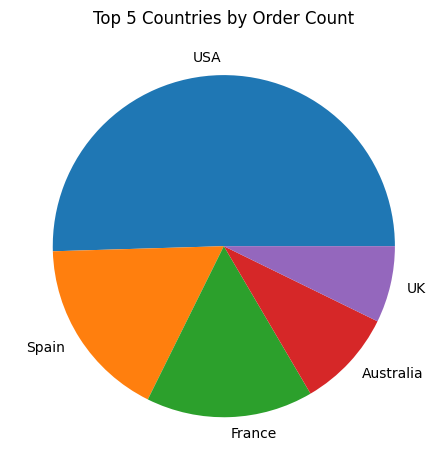

In [48]:
# Top 5 Countries - Pie Chart
top_five.plot(kind='pie')
plt.title('Top 5 Countries by Order Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

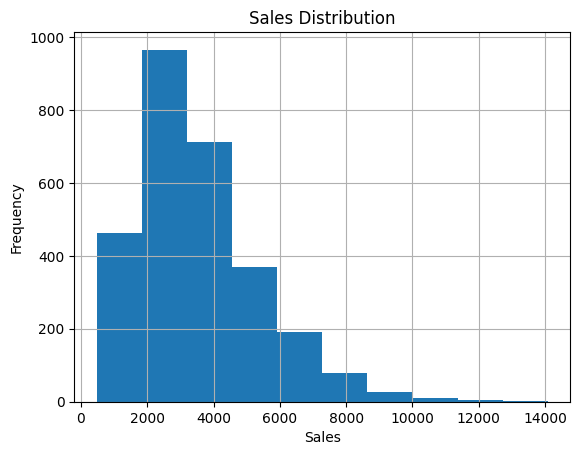

In [49]:
# Sales Distribution
df['SALES'].hist()
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

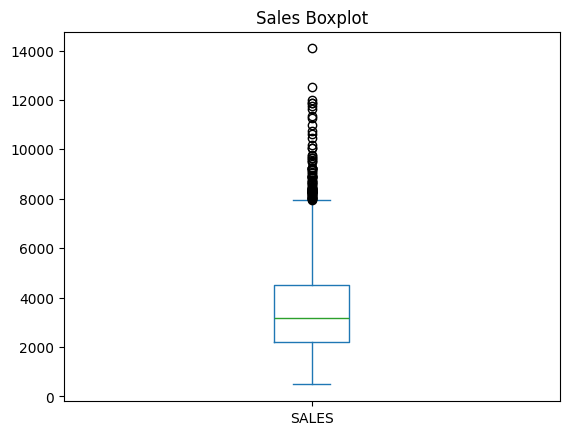

In [50]:
# Sales Boxplot
df['SALES'].plot(kind='box')
plt.title('Sales Boxplot')
plt.show()